In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import glob
from helper import *
from define_model import *
from my_helpers import *
import pprint as p
from sklearn.model_selection import train_test_split
from itertools import zip_longest
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.utils import shuffle
import seaborn as sns

In [3]:
drive = 0 # 1 if on google drive, 0 if not
data_dir = "/content/drive/MyDrive/chiliSummerProject/data/" if drive else "../data/"
model_path = "/content/drive/MyDrive/chiliSummerProject/models/" if drive else "../models/"
chili_models = model_path + "chili_models/"
identifier_eth = "TouchPose_crossGestures"
data_path_eth = data_dir + "eth_data/"
data_path_chili= data_dir + "processed/native_mapped/"
#set random seeds
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
files = glob.glob(data_path_eth+'*.pkl')
df_eth = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
print(len(df_eth))
df_eth.head()

65374


,cap_img,data_id,depth_img,filename,gesture_id,session_id,subject_id,touch_id
0,"[[0, 1, -1, 0, 5, -4, -2, -1, 2, 3, 0, -2, -1,...",3287.0,"[[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...",data_g_66_ 0_00003287.npz,66.0,right_hand_1,P01,0.0
1,"[[0, 2, 0, -5, -6, -7, -2, 0, -2, -1, 1, 1, -6...",3288.0,"[[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...",data_g_66_ 0_00003288.npz,66.0,right_hand_1,P01,0.0
2,"[[0, 1, -3, -4, 4, -1, 1, 1, -3, -1, 2, 0, 1, ...",3289.0,"[[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...",data_g_66_ 0_00003289.npz,66.0,right_hand_1,P01,0.0
3,"[[0, 4, 0, -1, -9, 4, 1, 0, 0, 1, 3, 1, -1, 2,...",3290.0,"[[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...",data_g_66_ 0_00003290.npz,66.0,right_hand_1,P01,0.0
4,"[[0, 3, 3, 0, -5, -5, -6, 3, 0, -1, 7, -4, 4, ...",3291.0,"[[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...",data_g_66_ 0_00003291.npz,66.0,right_hand_1,P01,0.0


In [5]:
files = glob.glob(data_path_chili+'*.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x.astype(np.float32))
max_skel = np.max(chili_data['skeleton'].apply(lambda x : np.max(x)))
max_cap = np.max(chili_data['cap_img'].apply(lambda x : np.max(x)))
#chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x/max_skel)
chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : x/max_cap)
print(chili_data.Timestamp.is_unique)
#chili_data.set_index('Timestamp', inplace=True)
#chili_data.sort_index(inplace=True)
print(len(chili_data))
chili_data.head()

True
82884


,Timestamp,skeleton,ScanSizeX,ScanSizeY,trial,gesture,subject,day,cap_img
0,1.680525e+12,"[[-249.0, 280.0, 127.0], [-227.0, 273.0, 102.0...",72,41,3,DT,34,0304,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,1.680525e+12,"[[-250.0, 280.0, 127.0], [-228.0, 273.0, 101.0...",72,41,3,DT,34,0304,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1.680525e+12,"[[-252.0, 281.0, 127.0], [-229.0, 274.0, 101.0...",72,41,3,DT,34,0304,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,1.680525e+12,"[[-255.0, 283.0, 129.0], [-236.0, 279.0, 100.0...",72,41,3,DT,34,0304,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1.680525e+12,"[[-254.0, 283.0, 129.0], [-235.0, 277.0, 100.0...",72,41,3,DT,34,0304,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


# Categorical features 

DT    26990
DQ    22777
LT    19709
LQ    13408
Name: gesture, dtype: int64

count     82884
unique        4
top          DT
freq      26990
Name: gesture, dtype: object

<AxesSubplot:>

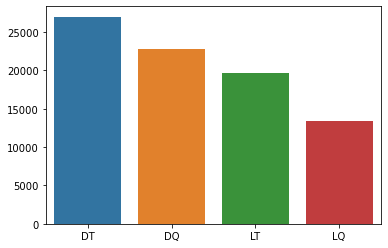

In [9]:
display(chili_data.gesture.value_counts())
display(chili_data.gesture.describe())
sns.barplot(x=chili_data.gesture.value_counts().index, y=chili_data.gesture.value_counts().values)

<AxesSubplot:>

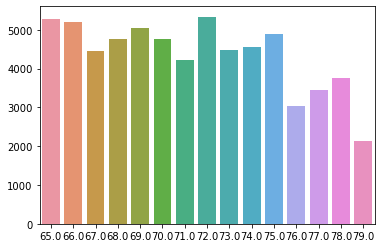

In [12]:
sns.barplot(x=df_eth.gesture_id.value_counts().index, y=df_eth.gesture_id.value_counts().values)

2    19991
1    17803
5    12704
6    12321
4    10730
3     9335
Name: trial, dtype: int64

count     82884
unique        6
top           2
freq      19991
Name: trial, dtype: object

<AxesSubplot:>

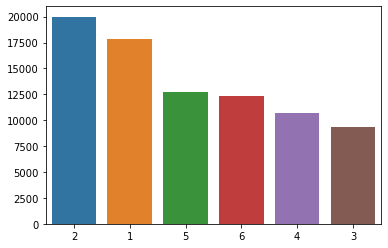

In [8]:
display(chili_data.trial.value_counts())
display(chili_data.trial.describe())
sns.barplot(x=chili_data.trial.value_counts().index, y=chili_data.trial.value_counts().values)

<AxesSubplot:>

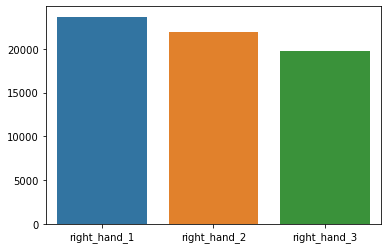

In [11]:
sns.barplot(x=df_eth.session_id.value_counts().index, y=df_eth.session_id.value_counts().values)

24    10545
14    10385
18    10027
19     9562
20     8055
27     6814
33     5752
13     5249
11     4046
25     2788
2      2206
10     1263
32     1206
12     1195
22     1143
17      769
28      561
35      411
16      375
5       295
29      183
21       36
1         9
34        9
Name: subject, dtype: int64

<AxesSubplot:>

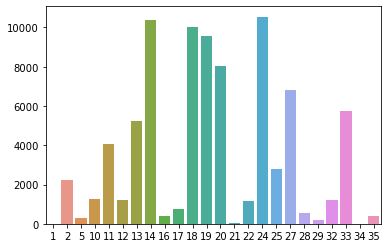

In [10]:
display(chili_data.subject.value_counts())
chili_data.subject.describe()
sns.barplot(x=chili_data.subject.value_counts().index, y=chili_data.subject.value_counts().values)

<AxesSubplot:>

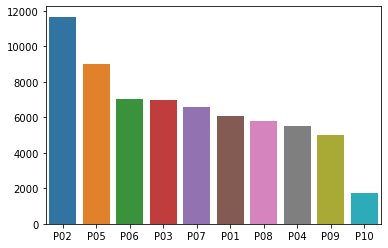

In [13]:
sns.barplot(x=df_eth.subject_id.value_counts().index, y=df_eth.subject_id.value_counts().values)

3003    44458
0304    14936
3103    14476
2903     6504
2803     2510
Name: day, dtype: int64

<AxesSubplot:>

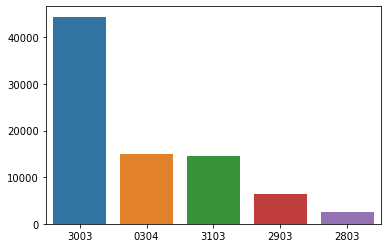

In [11]:
display(chili_data.day.value_counts())
chili_data.day.describe()
sns.barplot(x=chili_data.day.value_counts().index, y=chili_data.day.value_counts().values)

# Continuous features

In [8]:
cap_data = np.sort(np.concatenate(chili_data.cap_img.values).flatten())
sns.kdeplot(cap_data)

<AxesSubplot:ylabel='Density'>

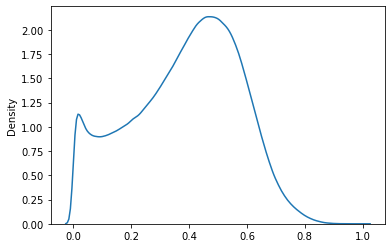

In [12]:
sns.kdeplot(cap_data)

<AxesSubplot:ylabel='Density'>

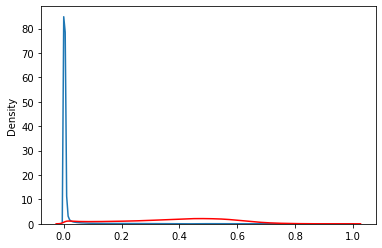

In [6]:
cap_data = np.sort(np.concatenate(chili_data.cap_img.values).flatten())
index = np.argwhere(cap_data==0)
cap_data = np.delete(cap_data,index)
cap_eth = np.sort(np.concatenate(df_eth.cap_img.values).flatten())
cap_eth = np.where(cap_eth > 0, cap_eth, 0)/1400
index = np.argwhere(cap_eth==0)
cap_eth = np.delete(cap_eth,index)
sns.kdeplot(cap_eth)
sns.kdeplot(cap_data, color='r')

<AxesSubplot:ylabel='Density'>

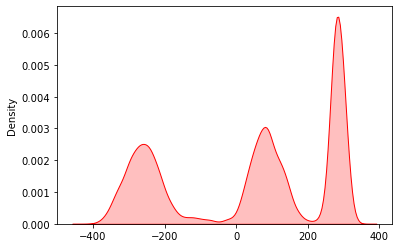

In [ ]:
# TODO keep each axis separate 
# 3d plot or axwise plot, 2d plot for each pair of axis, look more on internet.
skel_data = np.sort(np.concatenate(chili_data.skeleton.values).flatten()) 
sns.kdeplot(skel_data, shade=True, color="r")

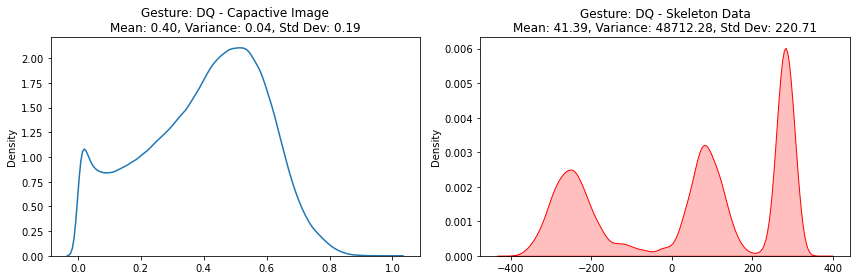

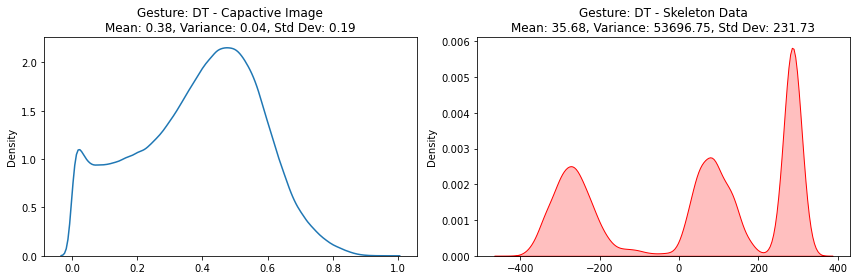

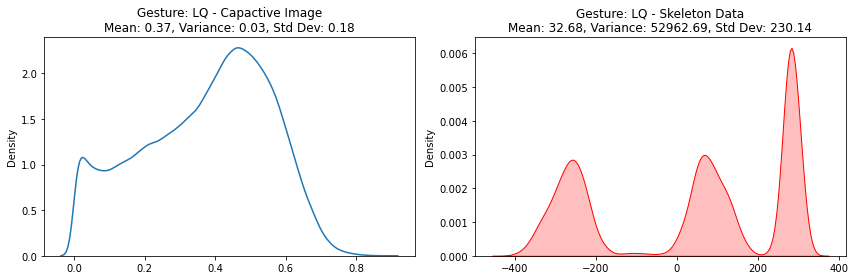

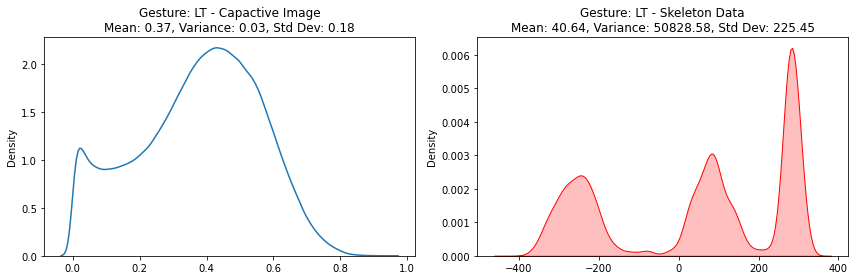

In [9]:
gesture_groups = chili_data.groupby('gesture')

for gesture, group_data in gesture_groups:
    cap_data = np.sort(np.concatenate(group_data.cap_img.values).flatten())
    index = np.argwhere(cap_data == 0)
    cap_data = np.delete(cap_data, index)
    
    skel_data = np.sort(np.concatenate(group_data.skeleton.values).flatten())
    
    cap_mean = np.mean(cap_data)
    cap_variance = np.var(cap_data)
    cap_std_dev = np.std(cap_data)
    
    skel_mean = np.mean(skel_data)
    skel_variance = np.var(skel_data)
    skel_std_dev = np.std(skel_data)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.kdeplot(cap_data, ax=axes[0])
    axes[0].set_title(f'Gesture: {gesture} - Capactive Image\nMean: {cap_mean:.2f}, Variance: {cap_variance:.2f}, Std Dev: {cap_std_dev:.2f}')

    sns.kdeplot(skel_data, ax=axes[1], shade=True, color="r")
    axes[1].set_title(f'Gesture: {gesture} - Skeleton Data\nMean: {skel_mean:.2f}, Variance: {skel_variance:.2f}, Std Dev: {skel_std_dev:.2f}')

    plt.tight_layout()
    plt.show()

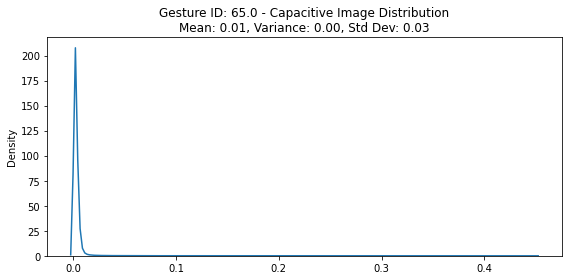

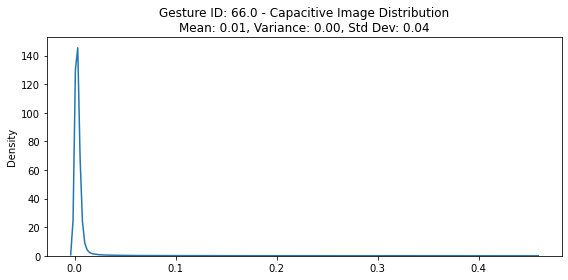

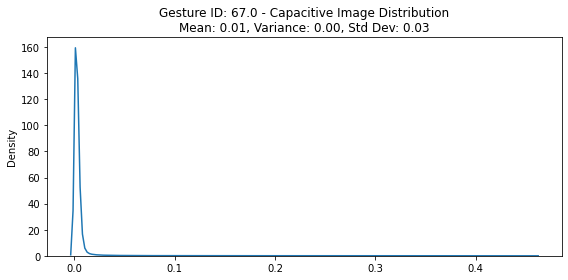

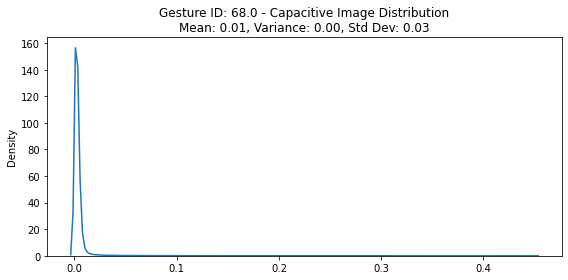

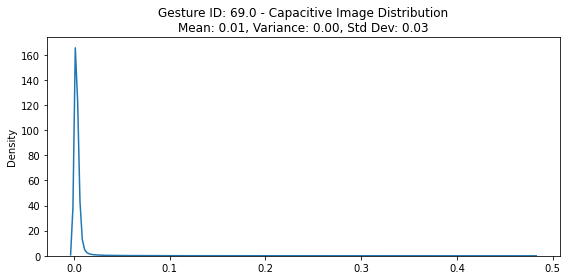

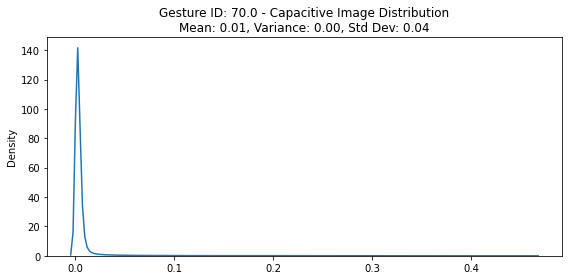

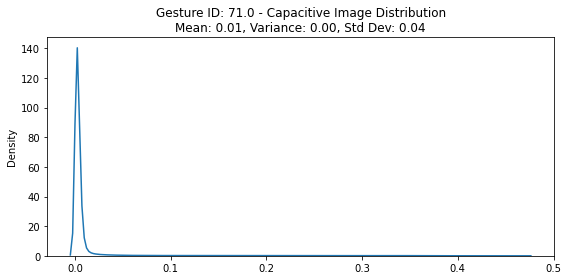

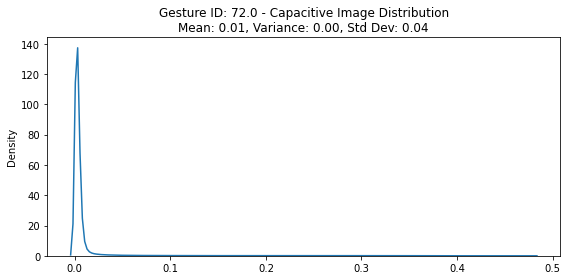

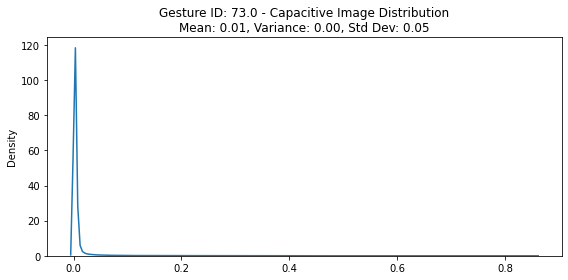

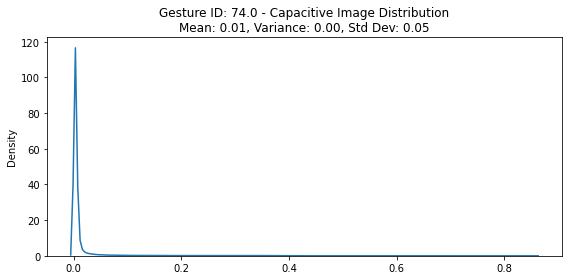

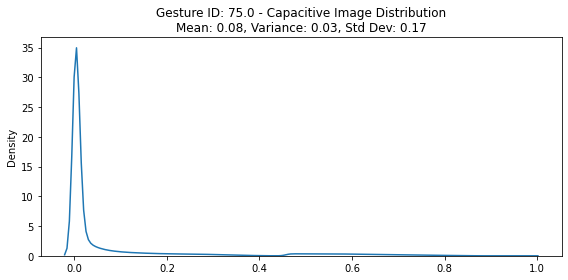

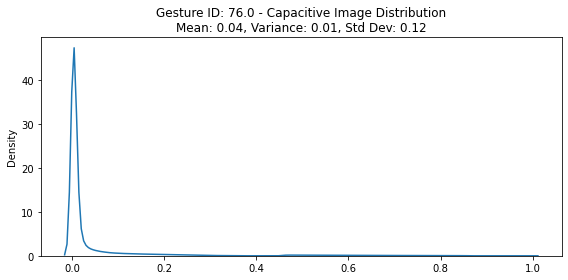

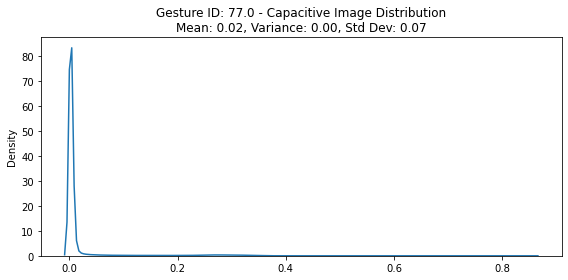

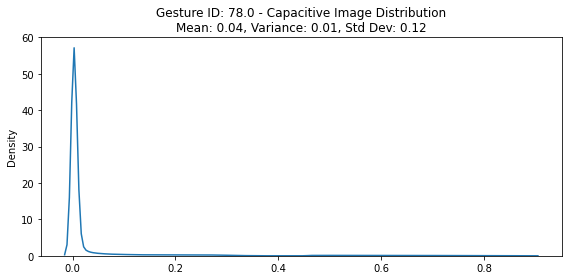

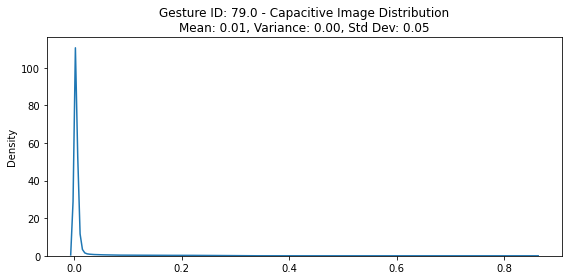

In [7]:
gesture_groups_eth = df_eth.groupby('gesture_id')

for gesture_id, group_data in gesture_groups_eth:
    cap_eth = np.sort(np.concatenate(group_data.cap_img.values).flatten())
    cap_eth = np.where(cap_eth > 0, cap_eth, 0) / 1400
    index = np.argwhere(cap_eth == 0)
    cap_eth = np.delete(cap_eth, index)
    
    cap_eth_mean = np.mean(cap_eth)
    cap_eth_variance = np.var(cap_eth)
    cap_eth_std_dev = np.std(cap_eth)

    plt.figure(figsize=(8, 4))

    sns.kdeplot(cap_eth)
    plt.title(f'Gesture ID: {gesture_id} - Capacitive Image Distribution\nMean: {cap_eth_mean:.2f}, Variance: {cap_eth_variance:.2f}, Std Dev: {cap_eth_std_dev:.2f}')

    plt.tight_layout()
    plt.show()